In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# ---------- 1. LOAD FILES ----------
# Adjust file paths if needed
ho_file = "LTE Cell Relations KE.csv"
kpi_file = "2025-09_RAN_data_LTE_800_KE(in).csv"

df_ho = pd.read_csv(ho_file)
df_kpi = pd.read_csv(kpi_file)

print("HO relations shape:", df_ho.shape)
print("KPI table shape:", df_kpi.shape)

df_ho.head(), df_kpi.head()

HO relations shape: (5370, 7)
KPI table shape: (555451, 18)


(  SITE_ID1 CELL_NAME1 RatBandShort SITE_ID2 CELL_NAME2 RatBandShort.1  \
 0    K1ALP    TK1ALP1          L08    K1ALP    SK1ALP1            L07   
 1    K1ALP    TK1ALP1          L08    K1ALP    TK1ALP2            L08   
 2    K1ALP    TK1ALP1          L08    K1ALP    VK1ALP2            L09   
 3    K1ALP    TK1ALP1          L08    K1BEN    TK1BEN2            L08   
 4    K1ALP    TK1ALP1          L08    K1KAV    TK1KAV2            L08   
 
    HO Execution Successes [#]  
 0                       17279  
 1                        2508  
 2                          74  
 3                           2  
 4                         988  ,
   base_station     cell       start_time  4g_usage_lte_800  \
 0        K1KAV  TK1KAV1  9/11/2025 12:30            3444.0   
 1        K1KAV  TK1KAV2  9/11/2025 12:30            3191.0   
 2        K1KAV  TK1KAV3  9/11/2025 12:30             465.0   
 3        K1KAV  TK1KAV1   9/11/2025 9:15            3421.0   
 4        K1KAV  TK1KAV2   9/11/2025 9:1

**Zoznam unikátnych buniek (node list)**

Zo stĺpca cell sme extrahovali zoznam všetkých unikátnych buniek v sieti. Tento zoznam definuje uzly grafu a určuje, pre koľko buniek budeme simultánne predikovať sieťové KPI. **формирует node list графа и задаёт размерность будущей GNN-модели**.

In [2]:
# ---------- 2. UNIQUE CELLS ----------
node_list = df_kpi["cell"].unique().tolist()
print("Number of unique cells:", len(node_list))
node_list[:10]

Number of unique cells: 197


['TK1KAV1',
 'TK1KAV2',
 'TK1KAV3',
 'TK2POV1',
 'TK2POV2',
 'TK2POV3',
 'TK1STR1',
 'TK1STR2',
 'TK1STR3',
 'TK2TOR1']

**Vytvorenie edge listu z handover dát**

Tabuľku handoverov sme transformovali na zoznam orientovaných hrán medzi bunkami s váhou zodpovedajúcou počtu úspešných handoverov. Výsledkom je grafová reprezentácia reálnych vzťahov medzi bunkami, ktorá zachytáva skutočné presuny používateľov v sieti. **основа для spatial part (GNN)**.

In [3]:
# ---------- 3. EDGE LIST ----------
# Columns: CELL_NAME1, CELL_NAME2, "HO Execution Successes [#]"

df_ho_clean = df_ho.rename(columns={
    "CELL_NAME1": "source",
    "CELL_NAME2": "target",
    "HO Execution Successes [#]": "ho_count"
})

# Remove self-loops (source == target)
df_ho_clean = df_ho_clean[df_ho_clean["source"] != df_ho_clean["target"]]

# Edge list
edge_list = df_ho_clean[["source", "target", "ho_count"]].copy()
edge_list["ho_count"].describe()

count      5370.000000
mean       5117.643203
std       17189.303511
min           0.000000
25%          86.000000
50%         635.000000
75%        3622.500000
max      676342.000000
Name: ho_count, dtype: float64

**Kontrola časovej synchronizácie KPI dát**

Časové značky KPI dát boli konvertované do jednotného formátu a zoradené v čase pre každú bunku. Analýza rozdielov medzi po sebe idúcimi časovými krokmi potvrdila konzistentný časový interval, čo umožňuje bezpečné použitie sekvenčných modelov.

In [4]:
# ---------- 4. TIME COLUMN CLEANING ----------
df_kpi["start_time"] = pd.to_datetime(df_kpi["start_time"], errors="coerce")

# Sort by time
df_kpi = df_kpi.sort_values("start_time")

# Check frequency per cell
freq_check = df_kpi.groupby("cell")["start_time"].apply(lambda x: x.diff().value_counts().head())
freq_check.head()

cell                    
TK1ALP1  0 days 00:15:00    2879
TK1ALP2  0 days 00:15:00    2879
TK1ARE1  0 days 00:15:00    2879
TK1ARE2  0 days 00:15:00    2879
TK1ARE3  0 days 00:15:00    2879
Name: start_time, dtype: int64

**Základná štatistika KPI podľa buniek**

KPI dáta boli zoskupené podľa buniek a boli vypočítané základné štatistické charakteristiky jednotlivých ukazovateľov. Výsledky ukazujú výraznú variabilitu záťaže medzi bunkami, čo naznačuje nerovnomerné rozdelenie prevádzky v sieti.

In [5]:
# ---------- 5. GROUP BY CELL ----------

# Select only numerical columns
numeric_cols = df_kpi.select_dtypes(include=[np.number]).columns
print("Numeric KPI columns:", list(numeric_cols))

grouped = df_kpi.groupby("cell")[numeric_cols]

# Now the aggregation works
basic_stats = grouped.agg(["mean", "std", "min", "max"])
basic_stats.head()

Numeric KPI columns: ['4g_usage_lte_800', '4g_usage_%_lte_800', 'cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800', 'cqi_tr3_4g_lte_800', 'cqi_tr4_4g_lte_800', 'rrc_users_4g_lte_800', 'max_rrc_users_4g_lte_800', 'data_volume_ul_4g_lte_800', 'data_volume_dl_4g_lte_800', 'active_users_ul_4g_lte_800', 'active_users_dl_4g_lte_800', 'max_active_users_ul_4g_lte_800', 'max_active_users_dl_4g_lte_800', 'mimo_rank_dl_4g_lte_800']


4g_usage_lte_800                              4g_usage_%_lte_800  \
                    mean          std    min      max               mean   
cell                                                                       
TK1ALP1      5006.114236  5432.185125   12.0  42980.0           5.562316   
TK1ALP2     14996.656597  9937.611240  293.0  43266.0          16.662986   
TK1ARE1        94.942708   788.846637    0.0  18292.0           0.105125   
TK1ARE2       117.561111  1054.362994    0.0  28079.0           0.130399   
TK1ARE3       253.029167   697.786447    0.0  18843.0           0.280955   

                                cqi_tr1_4g_lte_800            ...  \
               std   min    max               mean       std  ...   
cell                                                          ...   
TK1ALP1   6.035855  0.01  47.76          10.099083  1.393484  ...   
TK1ALP2  11.041822  0.33  48.07          11.524625  0.920613  ...   
TK1ARE1   0.876460  0.00  20.32           8.442868  6.309479  ...   
TK1ARE2   1.171556  0.00  31.20           7.022510  6.604756  ...   
TK1ARE3   0.775330  0.00  20.94          12.788812  2.101536  ...   

        max_active_users_ul_4g_lte_800        max_active_users_dl_4g_lte_800  \
                                   min    max                           mean   
cell                                                                           
TK1ALP1                            1.0   34.0                       1.118056   
TK1ALP2                            1.0    5.0                       1.713194   
TK1ARE1                            0.0  126.0                       1.387153   
TK1ARE2                            0.0   62.0                       0.889236   
TK1ARE3                            0.0  137.0                       3.748611   

                              mimo_rank_dl_4g_lte_800                        
              std  min    max                    mean       std   min   max  
cell                                                                         
TK1ALP1  0.349595  1.0    7.0                1.483885  0.324633  1.00  1.99  
TK1ALP2  0.725437  1.0    7.0                1.627646  0.218326  1.01  1.95  
TK1ARE1  4.487849  0.0  145.0                0.772580  0.562212  0.00  2.00  
TK1ARE2  3.354460  0.0  118.0                0.649198  0.607023  0.00  2.00  
TK1ARE3  6.444623  0.0  132.0                1.116201  0.180270  0.00  1.99  

[5 rows x 60 columns]

**Analýza dennej/týždennej sezónnosti (hodina dňa)**

Agregované KPI hodnoty boli analyzované v závislosti od hodiny dňa/dní v týždni. Pozorovali sme jasný denný cyklus so zvýšenou záťažou počas denných hodín/rozdiely medzi pracovnými dňami a víkendmi.

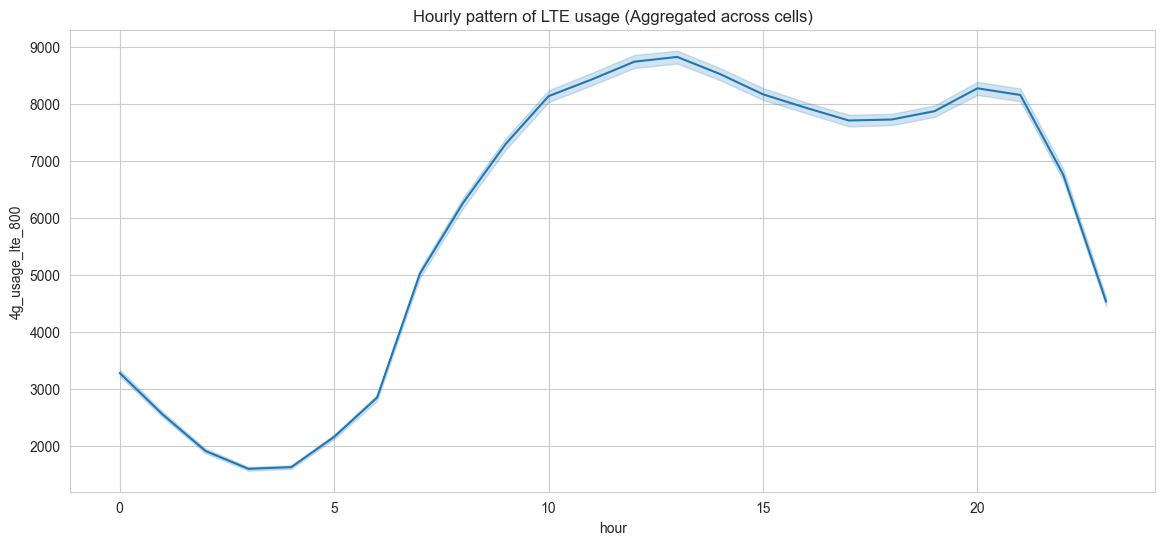

In [6]:
# Check seasons (periods) for hours/days
df_kpi["hour"] = df_kpi["start_time"].dt.hour
df_kpi["dayofweek"] = df_kpi["start_time"].dt.dayofweek

plt.figure(figsize=(14,6))
sns.lineplot(data=df_kpi, x="hour", y="4g_usage_lte_800")
plt.title("Hourly pattern of LTE usage (Aggregated across cells)")
plt.show()

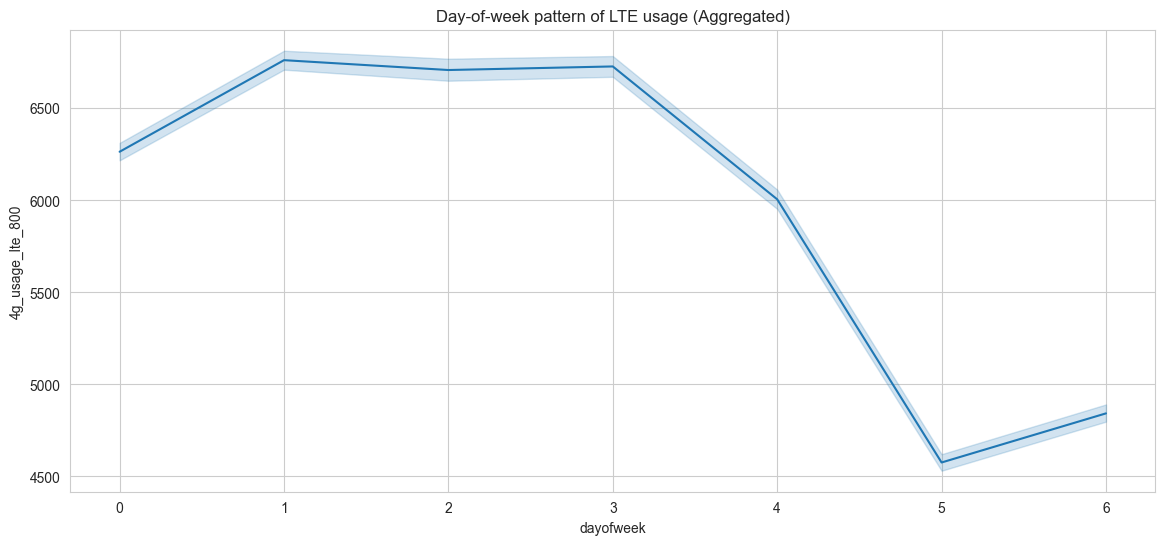

In [7]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df_kpi, x="dayofweek", y="4g_usage_lte_800")
plt.title("Day-of-week pattern of LTE usage (Aggregated)")
plt.show()

**Analýza chýbajúcich hodnôt v KPI dátach**

Bola vypočítaná relatívna miera chýbajúcich hodnôt pre jednotlivé KPI. Maximalne 2% missing data, co je ok asi?

In [8]:
# Missing values in %
missing = df_kpi.isna().mean().sort_values(ascending=False)
missing

active_users_dl_4g_lte_800        0.028273
active_users_ul_4g_lte_800        0.027295
rrc_users_4g_lte_800              0.021449
4g_usage_%_lte_800                0.021449
data_volume_ul_4g_lte_800         0.020753
max_rrc_users_4g_lte_800          0.020753
data_volume_dl_4g_lte_800         0.020753
4g_usage_lte_800                  0.020753
cqi_tr3_4g_lte_800                0.020753
cqi_tr4_4g_lte_800                0.020753
cqi_tr2_4g_lte_800                0.020753
cqi_tr1_4g_lte_800                0.020753
max_active_users_dl_4g_lte_800    0.020753
mimo_rank_dl_4g_lte_800           0.020753
max_active_users_ul_4g_lte_800    0.020753
base_station                      0.000000
start_time                        0.000000
cell                              0.000000
hour                              0.000000
dayofweek                         0.000000
dtype: float64

**Distribúcia handoverov a výber prahovej hodnoty** (порогового значения)

Rozdelenie počtu handoverov medzi bunkami má silne nerovnomerný charakter, pričom veľká časť vzťahov má veľmi nízku intenzitu. Zavedením prahovej hodnoty sme odstránili slabé a šumové väzby, čím sa zvýraznili len významné interakcie medzi bunkami.

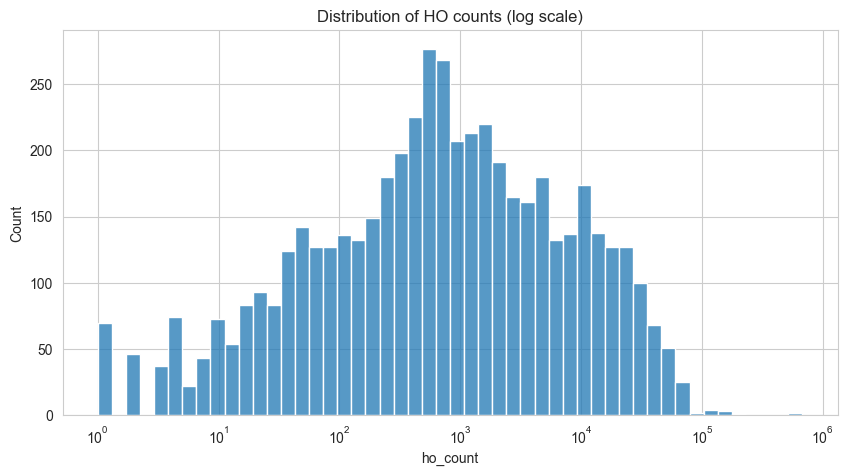

In [9]:
# HO Distribution to find threshold value
plt.figure(figsize=(10,5))
sns.histplot(edge_list["ho_count"], bins=50, log_scale=True)
plt.title("Distribution of HO counts (log scale)")
plt.show()

The histogram shows how many handovers occur between pairs of LTE cells, using a logarithmic scale on the x-axis. Most relations fall in the middle range (around 100–3000 HO counts), which represents strong and meaningful connections between neighboring cells. Very small values (below 10–50) appear rarely and usually represent noise or accidental handovers, not real interaction. Very large values (above 10 000) indicate highly active routes where users frequently move between specific cells, such as main roads or busy areas. Based on the shape of the distribution, a threshold around 100–150 removes noisy weak edges while keeping the most important and informative relationships. This threshold helps create a cleaner and more realistic graph structure for further modeling.

**Filtrovanie hrán podľa prahu**

Po aplikácii prahovej hodnoty sa počet hrán v grafe výrazne znížil (na 1585 zaznamov alebo ~30%), pričom zostali len prevádzkovo relevantné vzťahy. Takto zjednodušený graf je vhodnejší pre učenie GNN a znižuje riziko preučenia na náhodný šum.

In [10]:
threshold = 150
edges_filtered = edge_list[edge_list["ho_count"] >= threshold]
print("Edges before:", len(edge_list))
print("Edges after threshold:", len(edges_filtered))


Edges before: 5370
Edges after threshold: 3785


**Konštrukcia grafu siete LTE**

Z filtrovaných dát bol vytvorený **orientovaný graf, kde uzly reprezentujú bunky a hrany zachytávajú handoverové vzťahy s váhami**. Graf reprezentuje štruktúru siete.

In [11]:
# ---------- 10. NEIGHBOR GRAPH ----------
G = nx.DiGraph()

# Add nodes
G.add_nodes_from(node_list)

# Add edges with weights
for _, row in edges_filtered.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["ho_count"])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is directed:", G.is_directed())

Number of nodes: 593
Number of edges: 3785
Is directed: True


**Výber cieľového KPI (target)**

Analýza korelácií medzi hlavnými KPI ukázala, že ukazovatele záťaže, najmä 4g_usage_lte_800, silno súvisia s počtom používateľov a preneseným objemom dát. Tento KPI bol identifikovaný ako najvhodnejší cieľ pre predikciu, keďže najlepšie reprezentuje reálnu záťaž bunky.

**Výber cieľovej premennej (target KPI)**

Ako cieľová premenná pre predikciu bola zvolená metrika 4g_usage_lte_800, pretože priamo reprezentuje zaťaženie základňovej stanice a má vysoký praktický význam pre prevádzku mobilnej siete, najmä v kontexte load balancingu a kapacitného plánovania. Táto metrika vykazuje výraznú časovú dynamiku a sezónnosť a zároveň je ovplyvnená správaním susedných buniek.

Ostatné metriky, ako napríklad percentuálne vyjadrenie zaťaženia (4g_usage_%_lte_800), objemy prenesených dát (data_volume_ul_4g_lte_800, data_volume_dl_4g_lte_800) alebo počty aktívnych používateľov (active_users_ul_4g_lte_800, active_users_dl_4g_lte_800), sú v práci použité predovšetkým ako vstupné znaky, keďže nepriamo opisujú záťaž siete.

Ukazovatele rádiovej kvality (cqi_tr1_4g_lte_800, cqi_tr2_4g_lte_800, cqi_tr3_4g_lte_800, cqi_tr4_4g_lte_800) a fyzickej vrstvy (mimo_rank_dl_4g_lte_800) sú silne závislé od okamžitých rádiových podmienok a vykazujú vyšší stupeň šumu, čo ich robí menej vhodnými ako cieľ predikcie.

Premenné typu maximálnych hodnôt (max_rrc_users_4g_lte_800, max_active_users_ul_4g_lte_800, max_active_users_dl_4g_lte_800) majú prevažne konfiguračný charakter a minimálnu časovú variabilitu.

Počet prihlásených používateľov (rrc_users_4g_lte_800) je síce významným ukazovateľom správania siete, avšak v tejto práci slúži ako doplnková vstupná informácia.

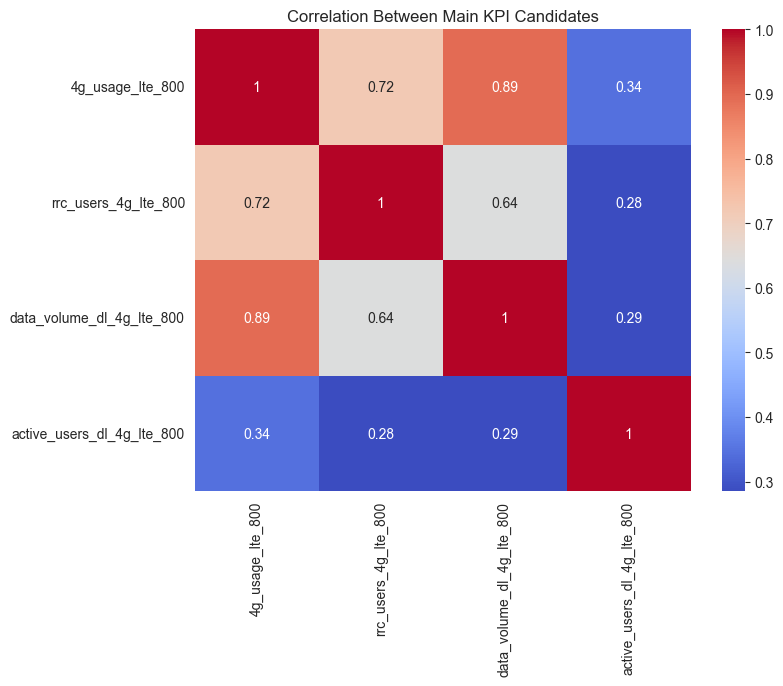

In [12]:
corr = df_kpi[["4g_usage_lte_800",
               "rrc_users_4g_lte_800",
               "data_volume_dl_4g_lte_800",
               "active_users_dl_4g_lte_800"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Main KPI Candidates")
plt.show()


Based on the correlation analysis, 4g_usage_lte_800 is the best choice for the target variable. It has the strongest relationship with the other KPIs, especially with downlink data volume and the number of RRC users, which means it reliably reflects overall cell load. This KPI is also stable, highly seasonal, and directly represents how heavily a cell is being used. Because cell load depends on the behavior of neighboring cells, 4g_usage_lte_800 is ideal for a graph-based forecasting model like a GNN. Other KPIs can still be used as features, but they are less suitable as the main prediction target.

# STAGE 1 — KPI Time-Series Data Engineering
## Load data and basic setup
**Spracovanie časovej osi KPI**

Dátum a čas meraní boli konvertované do štandardného formátu datetime a údaje boli zoradené podľa bunky a času. Týmto krokom sa zabezpečilo, že časové rady pre každú bunku sú chronologicky správne a pripravené na ďalšie spracovanie.

In [13]:
from sklearn.preprocessing import StandardScaler

# Parse datetime
df_kpi["start_time"] = pd.to_datetime(df_kpi["start_time"])

# Sort data
df_kpi = df_kpi.sort_values(["cell", "start_time"])

df_kpi.head()

,base_station,cell,start_time,4g_usage_lte_800,4g_usage_%_lte_800,cqi_tr1_4g_lte_800,cqi_tr2_4g_lte_800,cqi_tr3_4g_lte_800,cqi_tr4_4g_lte_800,rrc_users_4g_lte_800,max_rrc_users_4g_lte_800,data_volume_ul_4g_lte_800,data_volume_dl_4g_lte_800,active_users_ul_4g_lte_800,active_users_dl_4g_lte_800,max_active_users_ul_4g_lte_800,max_active_users_dl_4g_lte_800,mimo_rank_dl_4g_lte_800,hour,dayofweek
244781,K1ALP,TK1ALP1,2025-08-31 23:45:00,2110.0,2.34,10.34,7.97,0.0,0.0,3.16,5.0,14.45,141.05,1.41,0.99,2.0,1.0,1.0,23,6
244627,K1ALP,TK1ALP1,2025-09-01 00:00:00,186.0,0.21,9.89,10.98,0.0,0.0,3.23,5.0,4.03,7.59,1.13,0.95,1.0,1.0,1.0,0,0
244719,K1ALP,TK1ALP1,2025-09-01 00:15:00,263.0,0.29,10.45,13.18,0.0,0.0,4.57,7.0,15.44,7.74,2.11,0.94,5.0,1.0,1.0,0,0
244777,K1ALP,TK1ALP1,2025-09-01 00:30:00,363.0,0.40,10.33,12.53,0.0,0.0,5.01,7.0,5.03,22.44,1.21,0.97,1.0,1.0,1.0,0,0
244733,K1ALP,TK1ALP1,2025-09-01 00:45:00,327.0,0.36,10.23,11.38,0.0,0.0,4.17,7.0,3.89,18.95,1.12,0.97,1.0,1.0,1.0,0,0


## Define columns
**Definovanie identifikátorov, cieľa a vstupných príznakov**

Boli explicitne definované identifikačné stĺpce, cieľový KPI a množina vstupných príznakov používaných v modeli. Tento krok umožňuje jasne oddeliť predikovaný ukazovateľ od ostatných KPI a zabraňuje neúmyselnému použitiu identifikátorov ako numerických vstupov.

In [14]:
# Identifier columns
ID_COLS = ["cell", "start_time"]

# Target KPI (main prediction target)
TARGET_COL = "4g_usage_lte_800"

# KPI feature columns (exclude identifiers)
FEATURE_COLS = [
    col for col in df_kpi.columns
    if col not in ID_COLS and col != "base_station"
]


FEATURE_COLS

['4g_usage_lte_800',
 '4g_usage_%_lte_800',
 'cqi_tr1_4g_lte_800',
 'cqi_tr2_4g_lte_800',
 'cqi_tr3_4g_lte_800',
 'cqi_tr4_4g_lte_800',
 'rrc_users_4g_lte_800',
 'max_rrc_users_4g_lte_800',
 'data_volume_ul_4g_lte_800',
 'data_volume_dl_4g_lte_800',
 'active_users_ul_4g_lte_800',
 'active_users_dl_4g_lte_800',
 'max_active_users_ul_4g_lte_800',
 'max_active_users_dl_4g_lte_800',
 'mimo_rank_dl_4g_lte_800',
 'hour',
 'dayofweek']

## Create a global regular time grid
**Vytvorenie globálnej časovej mriežky**

Bol vytvorený jednotný časový index s krokom 15 minút, ktorý pokrýva celé sledované obdobie. Výsledný počet časových krokov (2880) zodpovedá 30 dňom meraní a tvorí základ pre synchronizáciu všetkých buniek.

In [15]:
# Global time index (15-minute resolution)
time_index = pd.date_range(
    start=df_kpi["start_time"].min(),
    end=df_kpi["start_time"].max(),
    freq="15min"
)

print("Total timesteps:", len(time_index)) # что это такое и зачем?


Total timesteps: 2880


## Reindex each cell to the global time grid
**Reindexácia časových radov podľa buniek**

Pre každú bunku boli KPI dáta zarovnané na spoločnú časovú mriežku pomocou reindexácie. Výsledkom je jednotná štruktúra dát pre všetkých 197 buniek, čo je nevyhnutné pre maticové a tenzorové reprezentácie v neurónových sieťach.

197 уникальных cell = узлов графа -> размерность N = 197.

In [16]:
cells = df_kpi["cell"].unique()
print("Number of cells:", len(cells))

cell_dfs = []

for cell in cells:
    temp = df_kpi[df_kpi["cell"] == cell].set_index("start_time")

    # Reindex to global timeline
    temp = temp.reindex(time_index)

    # Restore cell column
    temp["cell"] = cell

    cell_dfs.append(temp)

# Combine all cells back
df_kpi_grid = pd.concat(cell_dfs).reset_index()
df_kpi_grid = df_kpi_grid.rename(columns={"index": "start_time"})

Number of cells: 197


## Forward-fill missing KPI values
**Doplnenie chýbajúcich hodnôt pomocou forward fill**

Chýbajúce hodnoty KPI boli doplnené metódou forward fill (a následne backward fill na začiatku radu). Tento krok zabezpečuje kontinuitu časových radov a minimalizuje stratu dát pri zachovaní realistického správania KPI.

In [17]:
# Show which columns contain inf
inf_mask = np.isinf(df_kpi_grid[FEATURE_COLS])
inf_per_col = inf_mask.sum().sort_values(ascending=False)
print("Columns with inf:", inf_per_col[inf_per_col > 0])

# Replace +inf / -inf with NaN
df_kpi_grid[FEATURE_COLS] = df_kpi_grid[FEATURE_COLS].replace(
    [np.inf, -np.inf], np.nan
)

# Forward fill KPI features per cell
df_kpi_grid[FEATURE_COLS] = (
    df_kpi_grid
    .groupby("cell")[FEATURE_COLS]
    .ffill()
)

# Optional: backward fill remaining NaNs at the beginning
df_kpi_grid[FEATURE_COLS] = (
    df_kpi_grid
    .groupby("cell")[FEATURE_COLS]
    .bfill()
)

# Option A: use mean
# feature_fill_values = df_kpi_grid[FEATURE_COLS].mean()

# Option B: (more robust to outliers):
feature_fill_values = df_kpi_grid[FEATURE_COLS].median()

df_kpi_grid[FEATURE_COLS] = df_kpi_grid[FEATURE_COLS].fillna(feature_fill_values)

# Final check: there should be no missing values left
df_kpi_grid[FEATURE_COLS].isna().sum().sort_values(ascending=False).head()

Columns with inf: active_users_dl_4g_lte_800    1
dtype: int64


4g_usage_lte_800      0
4g_usage_%_lte_800    0
cqi_tr1_4g_lte_800    0
cqi_tr2_4g_lte_800    0
cqi_tr3_4g_lte_800    0
dtype: int64

## Add time-based features
**Rozšírenie dát o časové príznaky**

Do dát boli pridané časové príznaky reprezentujúce hodinu dňa, deň v týždni a víkend, vrátane cyklického kódovania pomocou sínus a kosínus funkcií. Tieto príznaky umožňujú modelu zachytiť dennú a týždennú sezónnosť v správaní mobilnej siete.

In [18]:
# Hour of day
df_kpi_grid["hour"] = df_kpi_grid["start_time"].dt.hour

# Day of week (0 = Monday)
df_kpi_grid["dayofweek"] = df_kpi_grid["start_time"].dt.dayofweek

# Cyclical encoding
df_kpi_grid["hour_sin"] = np.sin(2 * np.pi * df_kpi_grid["hour"] / 24)
df_kpi_grid["hour_cos"] = np.cos(2 * np.pi * df_kpi_grid["hour"] / 24)

df_kpi_grid["dow_sin"] = np.sin(2 * np.pi * df_kpi_grid["dayofweek"] / 7)
df_kpi_grid["dow_cos"] = np.cos(2 * np.pi * df_kpi_grid["dayofweek"] / 7)

# Weekend flag
df_kpi_grid["is_weekend"] = (df_kpi_grid["dayofweek"] >= 5).astype(int)

## Final feature list (KPI + time features)
**Zostavenie finálnej množiny vstupných príznakov**

Bola vytvorená finálna množina vstupných príznakov kombinujúca KPI a časové príznaky. Výsledkom je kompletný vektor vstupov, ktorý reprezentuje technický stav bunky aj časový kontext.

In [19]:
TIME_FEATURES = [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "is_weekend"
]

ALL_FEATURES = FEATURE_COLS + TIME_FEATURES
ALL_FEATURES


['4g_usage_lte_800',
 '4g_usage_%_lte_800',
 'cqi_tr1_4g_lte_800',
 'cqi_tr2_4g_lte_800',
 'cqi_tr3_4g_lte_800',
 'cqi_tr4_4g_lte_800',
 'rrc_users_4g_lte_800',
 'max_rrc_users_4g_lte_800',
 'data_volume_ul_4g_lte_800',
 'data_volume_dl_4g_lte_800',
 'active_users_ul_4g_lte_800',
 'active_users_dl_4g_lte_800',
 'max_active_users_ul_4g_lte_800',
 'max_active_users_dl_4g_lte_800',
 'mimo_rank_dl_4g_lte_800',
 'hour',
 'dayofweek',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'is_weekend']

## Train / Validation / Test split (time-based)
**Rozdelenie dát na trénovaciu, validačnú a testovaciu časť**

Časová os bola rozdelená na trénovaciu, validačnú a testovaciu časť v pomere 70 % / 15 % / 15 %.

In [20]:
# Unique sorted timestamps
all_times = df_kpi_grid["start_time"].unique()
all_times = np.sort(all_times)

n_total = len(all_times)

train_end = int(n_total * 0.7)
val_end   = int(n_total * 0.85)

train_times = all_times[:train_end]
val_times   = all_times[train_end:val_end]
test_times  = all_times[val_end:]

print("Train timesteps:", len(train_times))
print("Val timesteps:", len(val_times))
print("Test timesteps:", len(test_times))


Train timesteps: 2015
Val timesteps: 433
Test timesteps: 432


## Normalize features (fit on train only)
**Normalizácia vstupných príznakov**

Numerické vstupné príznaky boli normalizované pomocou štandardizácie, pričom parametre normalizácie boli vypočítané iba na trénovacej množine. Tento postup zaručuje numerickú stabilitu učenia a zabraňuje data leakage.

In [21]:
scaler = StandardScaler()

# Fit scaler on TRAIN data only
train_mask = df_kpi_grid["start_time"].isin(train_times)
scaler.fit(df_kpi_grid.loc[train_mask, ALL_FEATURES])

# Apply to all data
df_kpi_grid[ALL_FEATURES] = scaler.transform(
    df_kpi_grid[ALL_FEATURES]
)


## Build KPI tensor
**Vytvorenie tenzora vstupných dát KPI**

Časové rady KPI boli transformované do trojrozmerného tenzora s rozmermi [T, N, F], kde každá časová vzorka obsahuje stav všetkých buniek v sieti.

T — number of time steps -> 2880=30x96
N — number of cells (nodes) -> 197 BS
F — number of features (KPI + time features) -> 22

In [22]:
# Mapping cells to indices
cell_to_idx = {cell: i for i, cell in enumerate(cells)}

T = len(time_index)
N = len(cells)
F = len(ALL_FEATURES)

X = np.zeros((T, N, F), dtype=np.float32)

# Fill tensor
for t_idx, t in enumerate(time_index):
    temp = df_kpi_grid[df_kpi_grid["start_time"] == t]

    for _, row in temp.iterrows():
        n_idx = cell_to_idx[row["cell"]]
        X[t_idx, n_idx, :] = row[ALL_FEATURES].values

X.shape


(2880, 197, 22)

## Target tensor
**Vytvorenie cieľového tenzora (target)**

Cieľový KPI bol uložený do samostatného dvojrozmerného tenzora s rozmermi [T, N], ktorý reprezentuje hodnotu predikovanej veličiny pre každú bunku v každom časovom kroku. Tento tenzor slúži ako referenčný výstup pri učení modelu a umožňuje hodnotenie presnosti predikcie v čase a priestore.

In [23]:
y = np.zeros((T, N), dtype=np.float32)

for t_idx, t in enumerate(time_index):
    temp = df_kpi_grid[df_kpi_grid["start_time"] == t]

    for _, row in temp.iterrows():
        n_idx = cell_to_idx[row["cell"]]
        y[t_idx, n_idx] = row[TARGET_COL]

y.shape


(2880, 197)

# STAGE 2 — Graph Engineering (HO → Graph)

У нас есть:
* KPI таблица → там есть список клеток (cells), по которым есть временные ряды.
* HO таблица (handover relations) → там пары “cell1 → cell2” и число переходов ho_count.

Мы хотим из HO таблицы сделать граф, но только для тех клеток, по которым у нас есть KPI (чтобы модель могла учиться).

В итоге должны получить:
* edge_index (какие узлы соединены)
* edge_weight (насколько сильна связь)

## 2.1 Load and prepare HO edge list
**Príprava tabuľky vzťahov medzi bunkami**

Tabuľka handover vzťahov bola transformovaná do štandardnej podoby zdroj–cieľ–váha a boli odstránené samoprepojenia buniek. Výsledkom je prehľadný zoznam hrán, ktorý priamo reprezentuje interakcie medzi bunkami v sieti.

In [24]:
# Rename columns for clarity
df_ho_clean = df_ho.rename(columns={
    "CELL_NAME1": "source",
    "CELL_NAME2": "target",
    "HO Execution Successes [#]": "ho_count"
})

# Remove self-loops. Убираем “самопереходы” (клетка → она же), нам интересны между разными клетками.
df_ho_clean = df_ho_clean[df_ho_clean["source"] != df_ho_clean["target"]]

df_ho_clean.head()

,SITE_ID1,source,RatBandShort,SITE_ID2,target,RatBandShort.1,ho_count
0,K1ALP,TK1ALP1,L08,K1ALP,SK1ALP1,L07,17279
1,K1ALP,TK1ALP1,L08,K1ALP,TK1ALP2,L08,2508
2,K1ALP,TK1ALP1,L08,K1ALP,VK1ALP2,L09,74
3,K1ALP,TK1ALP1,L08,K1BEN,TK1BEN2,L08,2
4,K1ALP,TK1ALP1,L08,K1KAV,TK1KAV2,L08,988


## 2.1 Match KPI nodes with HO nodes
**Zladenie uzlov grafu s KPI dátami**

Bolo overené, že všetky bunky použité v grafe majú dostupné KPI dáta, pričom hrany s neznámymi uzlami boli odstránené.

Zistili sme, že 550 buniek sa nachádza iba v HO dátach, ale nemajú zodpovedajúce KPI merania. To znamena, že tabuľka handover vzťahov obsahuje širší kontext siete.

In [25]:
# KPI node set
# Собираем множество клеток из KPI (это “разрешённые” узлы)
kpi_nodes = set(cells)

# HO node set
# Собираем множество клеток из HO (все, которые встречаются в связях)
# Берём все клетки, которые встречаются как source + все клетки, которые встречаются как target = полный список узлов, которые фигурируют в HO файле
ho_nodes = set(df_ho_clean["source"]).union(set(df_ho_clean["target"]))

# Nodes present in HO but missing in KPI
# “лишние” клетки: есть в HO, но по ним нет KPI.
missing_nodes = ho_nodes - kpi_nodes
print("HO nodes missing in KPI:", len(missing_nodes))

# HO файл содержит связи для гораздо большего набора клеток, чем KPI-файл. Поэтому мы не можем использовать эти “лишние” клетки, иначе у модели будет ребро на узел, у которого нет признаков.

HO nodes missing in KPI: 550


In [26]:
# Remove edges with unknown nodes
df_ho_matched = df_ho_clean[
    df_ho_clean["source"].isin(kpi_nodes) &
    df_ho_clean["target"].isin(kpi_nodes)
]

print("Edges before filtering:", len(df_ho_clean))
print("Edges after filtering:", len(df_ho_matched))


Edges before filtering: 5370
Edges after filtering: 3764


Po odstránení hrán grafová štruktúra je plne konzistentná so vstupnými dátami modelu a každá hrana reprezentuje reálne pozorovateľnú interakciu medzi dvoma bunkami.

## 2.2 Threshold analysis — how many edges/components?
**Analýza prahovej hodnoty pre výber hrán**

Bol analyzovaný vplyv rôznych prahových hodnôt handoverov na počet hrán a konektivitu grafu. Tento krok umožnil zvoliť taký prah, ktorý odstráni šumové väzby, no zároveň zachová súvislú štruktúru siete.

In [27]:
# список порогов: мы пробуем разные уровни
thresholds = [0, 10, 50, 100, 150, 200, 300, 500]

# будем записывать, сколько ребер осталось при каждом пороге
edge_counts = []
# сколько “кусочков” (компонент связности) получится.
component_counts = []

for th in thresholds:
    temp_edges = df_ho_matched[df_ho_matched["ho_count"] >= th] # оставляем только очень сильные связи

    G = nx.Graph() # создаём неориентированный граф
    G.add_nodes_from(cells) # добавляем все 197 узлов, даже если у них нет ребер
    G.add_edges_from(zip(temp_edges["source"], temp_edges["target"]))

    edge_counts.append(len(temp_edges))
    component_counts.append(nx.number_connected_components(G))


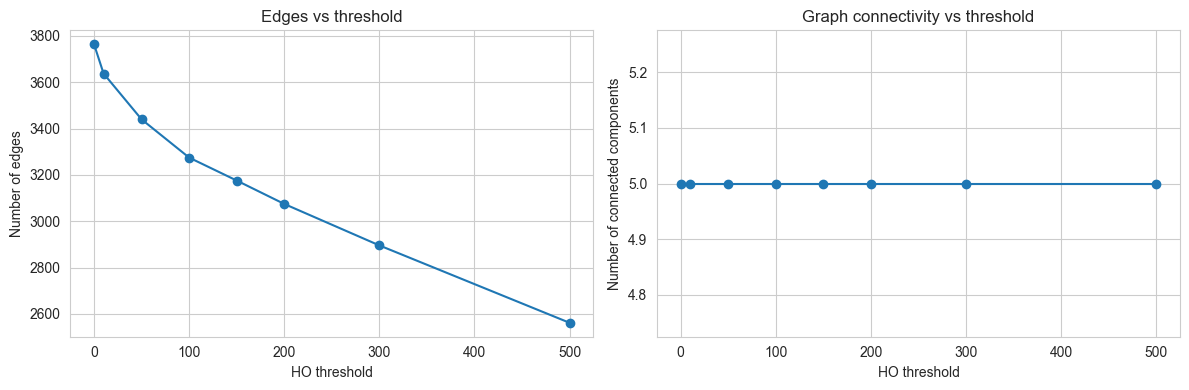

In [28]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(thresholds, edge_counts, marker="o")
plt.xlabel("HO threshold")
plt.ylabel("Number of edges")
plt.title("Edges vs threshold")

plt.subplot(1,2,2)
plt.plot(thresholds, component_counts, marker="o")
plt.xlabel("HO threshold")
plt.ylabel("Number of connected components")
plt.title("Graph connectivity vs threshold")

plt.tight_layout()
plt.show()

#TODO treshhold podla ho_count???


**Analýza počtu hrán v závislosti od prahovej hodnoty HO**
Analýza ukázala, že so zvyšujúcou prahovou hodnotou handoverov počet hrán v grafe postupne sa klesá, čo naznačuje odstránenie slabých a potenciálne šumových väzieb. Zároveň je zrejmé, že aj pri vyšších prahoch zostáva graf dostatočne bohatý na reprezentáciu relevantných interakcií medzi bunkami.

Teda handover vzťahy majú prirodzene dlhý chvost rozdelenia.

**Konektivita grafu pri rôznych prahoch HO**
Počet súvislých komponentov grafu zostáva konštantný (5) pre všetky testované prahové hodnoty. Znamená, že graf sa ani pri agresívnejšom filtrovaní nerozpadá na izolované časti a zachováva globálnu konektivitu siete.

Teda sieť má robustnú topológiu s viacerými silne prepojenými klastrami, ktoré zostávajú stabilné aj po odstránení slabých väzieb.

## 2.2 Alternative: Top-k neighbors per cell
**Výber najvýznamnejších susedov pomocou top-k prístupu**

Namiesto globálneho prahu bol použitý prístup top-k, ktorý zachováva len najsilnejšie väzby pre každú bunku. Tento prístup zaručuje, že každá bunka má reprezentatívne susedstvo.

In [29]:
k = 5  # number of strongest neighbors per cell

df_topk = (
    df_ho_matched
    .sort_values("ho_count", ascending=False)
    .groupby("source")
    .head(k)
)

print("Edges after top-k filtering:", len(df_topk))


Edges after top-k filtering: 944


Použitím top-k prístupu (k = 5) sa počet hrán znížil na 944, pričom každá bunka si zachovala svoje najsilnejšie interakcie.

Для каждой клетки source мы оставляем только 5 самых сильных соседей по ho_count. У некоторых клеток может быть 100 соседей (шум), а у некоторых 2 (и тогда threshold может их убить). Почему получилось 944, а не 197×5=985: потому что у некоторых source меньше 5 связей в данных, какие-то связи могли быть удалены ранее (узлы не из KPI)

## 2.3 Edge weight transformation
**Transformácia a normalizácia váh hrán**

Váhy hrán boli transformované pomocou logaritmickej funkcie a následne normalizované po zdrojových uzloch. Tento krok zlepšuje numerickú stabilitu učenia a umožňuje modelu porovnávať relatívnu silu susedských vzťahov.

In [30]:
# Log-transform edge weights
# ho_count может быть очень большой (тысячи/десятки тысяч) и лог “сжимает” масштаб, чтобы модель не сходила с ума
df_topk["edge_weight"] = np.log1p(df_topk["ho_count"])

# Row-normalize edge weights (outgoing normalization)
# GNN будет “смешивать соседей” пропорционально весам =1
df_topk["edge_weight"] = (
    df_topk["edge_weight"] /
    df_topk.groupby("source")["edge_weight"].transform("sum")
)

## 2.4 Build edge_index and edge_weight
**Vytvorenie grafovej reprezentácie pre GNN**

Graf bol prevedený do formátu edge_index a edge_weight, ktorý je priamo kompatibilný s knižnicou PyTorch Geometric.

In [31]:
# Map cells to indices
# Нейросети не понимают строковые имена клеток типа "TK1ALP1", Им нужны числа
cell_to_idx = {cell: i for i, cell in enumerate(cells)}

# Build edge_index and edge_weight
edge_index = np.array([
    df_topk["source"].map(cell_to_idx).values,
    df_topk["target"].map(cell_to_idx).values
], dtype=np.int64)

edge_weight = df_topk["edge_weight"].values.astype(np.float32)

edge_index.shape, edge_weight.shape


((2, 944), (944,))

Rozmer výsledných objektov potvrdzuje, že graf obsahuje 944 orientovaných hrán pripravených na použitie v GNN modeli.

# STAGE 3 — Temporal Windowing & Dataset
## 3.1 Temporal windowing logic

**Tvorba časových okien (temporal windowing)**

Vstupné dáta boli rozdelené na posuvné časové okná, kde každá vzorka obsahuje históriu dĺžky L a zodpovedajúci cieľ v budúcnosti.

In [32]:
import torch
from torch.utils.data import Dataset, DataLoader

# Window parameters
HISTORY_LENGTH = 8   # L: number of past timesteps (e.g. 2 hours = 8 × 15 min)
FORECAST_HORIZON = 1 # H: number of future timesteps to predict

class TemporalWindowDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, history_len, horizon):
        """
        X: numpy array of shape [T, N, F]
        y: numpy array of shape [T, N]
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.history_len = history_len
        self.horizon = horizon
        self.T = X.shape[0] # Получаем количество временных шагов

        # Valid starting indices for windows
        # Создаём список допустимых центральных времён t
        self.indices = list(range(history_len, self.T - horizon + 1))

    # Возвращаем количество окон
    def __len__(self):
        return len(self.indices)

    # Берём конкретный временной центр окна
    def __getitem__(self, idx):
        t = self.indices[idx]

        # Input window: [t-L, ..., t-1] - Берём L шагов истории
        X_window = self.X[t - self.history_len : t]

        # Target window: [t, ..., t+H-1] - Берём H шагов вперёд
        y_window = self.y[t : t + self.horizon]

        return X_window, y_window, t


## 3.2 Time-based train / val / test split
**Časové rozdelenie dát na trénovaciu, validačnú a testovaciu množinu**

Dáta boli rozdelené striktne podľa času na trénovaciu, validačnú a testovaciu časť v pomere 70 % / 15 % / 15 %.

**Samples = T - L - H + 1**


In [33]:
T = X.shape[0] # Мы берём первую размерность тензора. X.shape = (2880, 197, 22) -> T = 2880. Это общее количество временных шагов.

train_end = int(T * 0.7)
val_end   = int(T * 0.85)

# Create datasets using time-based slicing
train_dataset = TemporalWindowDataset(
    X[:train_end],
    y[:train_end],
    HISTORY_LENGTH,
    FORECAST_HORIZON
)

val_dataset = TemporalWindowDataset(
    X[train_end:val_end],
    y[train_end:val_end],
    HISTORY_LENGTH,
    FORECAST_HORIZON
)

test_dataset = TemporalWindowDataset(
    X[val_end:],
    y[val_end:],
    HISTORY_LENGTH,
    FORECAST_HORIZON
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Train samples: 2007
Val samples: 425
Test samples: 424


## 3.3 DataLoaders

**Príprava DataLoaderov pre učenie modelu**


In [34]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True # нам важен порядок времени
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## 3.4 Inspect one batch (sanity check)
**Overenie tvaru vstupných a cieľových dávok**

Bol vykonaný kontrolný výpis rozmerov jednej dávky dát, aby sa overila správnosť tvaru vstupov a výstupov.

The model receives 8 time slices, each slice representing the entire network, each cell representing 22 parameters.

In [35]:
X_batch, y_batch, t_batch = next(iter(train_loader))

print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)

X_batch shape: torch.Size([16, 8, 197, 22])
y_batch shape: torch.Size([16, 1, 197])


# STAGE 4 — Baseline Models
## 4.1 Persistence, Seasonal naive and Linear baseline

Perzistentný model predpokladá, že budúca hodnota KPI je rovnaká ako posledná známa hodnota.

Sezónny model využíva hodnotu KPI z rovnakého času predchádzajúceho dňa ako predikciu.

Lineárny model využíva celé historické okno ako jeden vstupný vektor bez explicitného modelovania časovej dynamiky.

In [36]:
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error

# считает ошибки между настоящими значениями и предсказаниями
def evaluate_predictions(y_true, y_pred):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    mse = mean_squared_error(y_true, y_pred) # MSE = средняя квадратичная
    mae = mean_absolute_error(y_true, y_pred) # MAE = средняя абсолютная ошибка
    rmse = np.sqrt(mse) # RMSE = корень из MSE

    return mse, mae, rmse

# Persistence baseline
def persistence_baseline(loader):
    all_preds = []
    all_true = []

    for X_batch, y_batch, t_batch in loader:
        # Last timestep from history
        y_pred = X_batch[:, -1, :, 0]  # assuming target is feature index 0
        y_true = y_batch[:, 0, :]

        all_preds.append(y_pred.numpy())
        all_true.append(y_true.numpy())

    return np.concatenate(all_true), np.concatenate(all_preds)

def seasonal_baseline(loader, full_y, seasonal_lag=96):
    all_preds = []
    all_true = []

    for X_batch, y_batch, t_batch in loader:

        batch_preds = []
        batch_true = []

        for t in t_batch:
            t = t.item()

            if t - seasonal_lag >= 0:
                y_pred = torch.tensor(full_y[t - seasonal_lag])
            else:
                y_pred = torch.tensor(full_y[t - 1])

            batch_preds.append(y_pred)
            batch_true.append(torch.tensor(full_y[t]))

        batch_preds = torch.stack(batch_preds)
        batch_true = torch.stack(batch_true)

        all_preds.append(batch_preds.numpy())
        all_true.append(batch_true.numpy())

    return np.concatenate(all_true), np.concatenate(all_preds)


# Seasonal naive baseline
def seasonal_baseline2(loader, seasonal_lag=96):
    all_preds = []
    all_true = []

    for X_batch, y_batch, t_batch in loader:
        if HISTORY_LENGTH >= seasonal_lag:
            y_pred = X_batch[:, -seasonal_lag, :, 0]
        else:
            y_pred = X_batch[:, -1, :, 0]

        y_true = y_batch[:, 0, :]
        all_preds.append(y_pred.numpy())
        all_true.append(y_true.numpy())

    # check
    print("HISTORY_LENGTH =", HISTORY_LENGTH, "seasonal_lag =", seasonal_lag)
    print("Using seasonal branch?", HISTORY_LENGTH >= seasonal_lag)

    return np.concatenate(all_true), np.concatenate(all_preds)

# Linear baseline (flatten history)
class LinearBaseline(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        B, L, N, F = x.shape
        x = x.reshape(B, L * N * F)
        return self.linear(x)

def train_linear(model, loader, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        for X_batch, y_batch, t_batch in loader:
            y_true = y_batch[:, 0, :]

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_true)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

## 4.2 LSTM per-cell (no graph)

**LSTM model bez grafovej štruktúry**
Rekurentná neurónová sieť typu LSTM modeluje časovú dynamiku KPI pre každú bunku nezávisle.

In [37]:
class LSTMBaseline(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_cells):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.num_cells = num_cells

    def forward(self, x):
        B, L, N, F = x.shape

        x = x.permute(0, 2, 1, 3)  # [B, N, L, F]
        x = x.reshape(B * N, L, F)

        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)

        out = out.reshape(B, N)
        return out

def train_lstm(model, loader, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        for X_batch, y_batch, t_batch in loader:
            y_true = y_batch[:, 0, :]

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_true)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

## 4.3 Evaluation & Visualization of baselines

Presnosť jednotlivých baseline modelov bola vyhodnotená pomocou metrík MSE, MAE a RMSE. Výsledná tabuľka poskytuje referenčné hodnoty, ktoré budú použité na porovnanie s grafovými modelmi.

In [38]:
results = {}

# Persistence
y_true, y_pred = persistence_baseline(test_loader)
results["Persistence"] = evaluate_predictions(y_true, y_pred)

# Seasonal
y_true, y_pred = seasonal_baseline(test_loader, y)
results["Seasonal"] = evaluate_predictions(y_true, y_pred)

results

{'Persistence': (0.22896209359169006,
  0.27689632773399353,
  np.float64(0.47849983656391154)),
 'Seasonal': (0.42149993777275085,
  0.3689247667789459,
  np.float64(0.6492302656013126))}

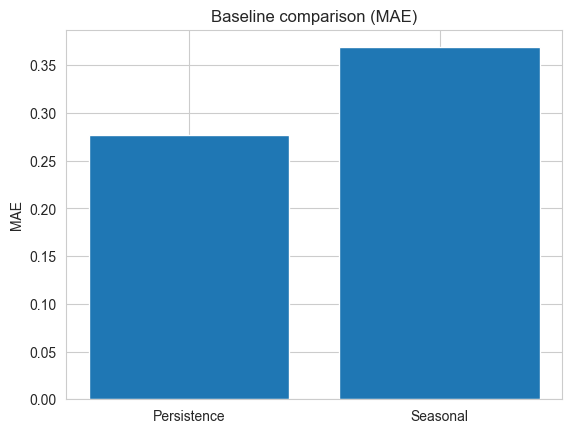

In [39]:
model_names = list(results.keys())
mae_scores = [results[m][1] for m in model_names]

plt.figure()
plt.bar(model_names, mae_scores)
plt.ylabel("MAE")
plt.title("Baseline comparison (MAE)")
plt.show()

In [40]:
cell_id = 0

print("True:", y_true[:10, cell_id])
print("Pred:", y_pred[:10, cell_id])


True: [-0.7847983  -0.702079   -0.751082   -0.7757978  -0.6600764  -0.75636804
 -0.78394115 -0.7669401  -0.78694135 -0.75808245]
Pred: [-0.7743691  -0.7847983  -0.702079   -0.751082   -0.7757978  -0.6600764
 -0.75636804 -0.78394115 -0.7669401  -0.78694135]


In [41]:
errors = np.abs(y_true - y_pred)
print("Mean error:", errors.mean())
print("Max error:", errors.max())


Mean error: 0.36892477
Max error: 5.7852125


# STAGE 5 - Realization ST-GNN

Určenie indexu cieľového KPI v zozname príznakov
Bol identifikovaný presný index cieľového KPI vo vektoroch vstupných príznakov, aby model pracoval s korektnou veličinou.

In [42]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# PyTorch Geometric layers
try:
    from torch_geometric.nn import GCNConv, SAGEConv
except ImportError as e:
    raise ImportError(
        "torch_geometric is not installed. "
        "Install it first (PyG). Then rerun this cell."
    )

def unpack_batch(batch):
    """
    Supports both:
      - (X_batch, y_batch)
      - (X_batch, y_batch, t_batch)
    """
    if len(batch) == 2:
        return batch[0], batch[1]
    elif len(batch) == 3:
        return batch[0], batch[1]
    else:
        raise ValueError("Unexpected batch format.")

# Make sure target is inside ALL_FEATURES
target_idx = ALL_FEATURES.index(TARGET_COL)
print("Target feature:", TARGET_COL, "-> index in ALL_FEATURES:", target_idx)

C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target feature: 4g_usage_lte_800 -> index in ALL_FEATURES: 0


## build batched edge_index (repeat graph for each item in batch)
Keďže každá vzorka v batchi zdieľa rovnakú topológiu siete, graf bol zopakovaný pre celý batch pomocou posunu indexov uzlov.

Например, у нас есть 1 граф из 197 клеток, но в батче 16 примеров. Нужно: сделать 16 копий графа и сдвинуть индексы узлов.

In [43]:
def make_batched_edge_index(edge_index, num_nodes, batch_size, device):
    """
    Repeats the same graph batch_size times by offsetting node indices.
    edge_index: [2, E]
    returns: [2, batch_size * E]
    """
    E = edge_index.size(1)
    edge_index = edge_index.to(device)

    # Offsets: 0, N, 2N, ...
    offsets = (torch.arange(batch_size, device=device) * num_nodes).repeat_interleave(E)
    batched_edge_index = edge_index.repeat(1, batch_size) + offsets

    return batched_edge_index


## Model 1: GCN + GRU
Najprv sa na každom časovom kroku použije GCN na agregáciu informácií zo susedných buniek a následne GRU modeluje časovú dynamiku získaných priestorových reprezentácií.


In [45]:
class GCN_GRU(nn.Module):
    def __init__(self, in_features, gnn_hidden, rnn_hidden, num_nodes, edge_weighted=True, dropout=0.1):
        super().__init__()
        self.num_nodes = num_nodes
        self.edge_weighted = edge_weighted

        # GCNConv = графовая свёртка. Spatial part.
        # GCN: новое значение клетки = среднее её соседей + она сама
        self.gcn = GCNConv(in_features, gnn_hidden, add_self_loops=True, normalize=True)
        # GRU = слой памяти. Temporal part.
        # GRU: Смотри на последовательность и пойми тренд
        self.gru = nn.GRU(input_size=gnn_hidden, hidden_size=rnn_hidden, batch_first=True)
        # взять скрытые признаки → превратить в одно число
        self.out = nn.Linear(rnn_hidden, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, X_batch, edge_index, edge_weight=None):
        """
        X_batch: [B, L, N, F] - input
        Output:  [B, N]
        """
        B, L, N, F = X_batch.shape
        device = X_batch.device

        # Build batched edge_index once per forward
        batched_edge_index = make_batched_edge_index(edge_index, N, B, device)

        # Repeat edge weights if used
        if self.edge_weighted and edge_weight is not None:
            ew = edge_weight.to(device).repeat(B)  # [B*E]
        else:
            ew = None

        # Apply GCN for each timestep in the history window
        # We take each of the 8 temporary steps.
        spatial_seq = []
        for t in range(L):
            # All batches. One moment in time. All stations
            x_t = X_batch[:, t, :, :]          # [B, N, F]
            x_t = x_t.reshape(B * N, F)        # [B*N, F] [number_of_nodes, attributes]

            # Each station looks at its neighbors. Takes their characteristics. Updates itself. So, the station load now takes neighbors into account.
            h_t = self.gcn(x_t, batched_edge_index, ew)  # [B*N, gnn_hidden]
            h_t = torch.relu(h_t)
            h_t = self.dropout(h_t)

            h_t = h_t.reshape(B, N, -1)        # [B, N, gnn_hidden]
            spatial_seq.append(h_t)

        # Stack over time: [B, L, N, gnn_hidden]
        spatial_seq = torch.stack(spatial_seq, dim=1)

        # GRU expects [batch, seq, features], so treat each node as an independent sequence:
        # [B, L, N, gnn_hidden] -> [B*N, L, gnn_hidden]
        spatial_seq = spatial_seq.permute(0, 2, 1, 3).reshape(B * N, L, -1)

        rnn_out, _ = self.gru(spatial_seq)     # [B*N, L, rnn_hidden]
        last = rnn_out[:, -1, :]               # [B*N, rnn_hidden]

        y_pred = self.out(last)                # [B*N, 1]
        y_pred = y_pred.reshape(B, N)          # [B, N]
        return y_pred

## Model 2: GraphSAGE + GRU
GraphSAGE agreguje informácie zo susedov spôsobom, ktorý je často stabilnejší pri nerovnomerných stupňoch uzlov v reálnych sieťach, a GRU následne modeluje časový vývoj.

In [46]:
class SAGE_GRU(nn.Module):
    def __init__(self, in_features, gnn_hidden, rnn_hidden, num_nodes, dropout=0.1):
        super().__init__()
        self.num_nodes = num_nodes

        self.sage = SAGEConv(in_features, gnn_hidden)  # GraphSAGE (mean aggregation by default)
        self.gru = nn.GRU(input_size=gnn_hidden, hidden_size=rnn_hidden, batch_first=True)
        self.out = nn.Linear(rnn_hidden, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, X_batch, edge_index):
        """
        X_batch: [B, L, N, F]
        Output:  [B, N]
        """
        B, L, N, F = X_batch.shape
        device = X_batch.device

        batched_edge_index = make_batched_edge_index(edge_index, N, B, device)

        spatial_seq = []
        for t in range(L):
            x_t = X_batch[:, t, :, :].reshape(B * N, F)
            h_t = self.sage(x_t, batched_edge_index)    # [B*N, gnn_hidden]
            h_t = torch.relu(h_t)
            h_t = self.dropout(h_t)
            spatial_seq.append(h_t.reshape(B, N, -1))

        spatial_seq = torch.stack(spatial_seq, dim=1)   # [B, L, N, gnn_hidden]
        spatial_seq = spatial_seq.permute(0, 2, 1, 3).reshape(B * N, L, -1)

        rnn_out, _ = self.gru(spatial_seq)
        last = rnn_out[:, -1, :]
        y_pred = self.out(last).reshape(B, N)
        return y_pred

## Training + evaluation loops
Bol implementovaný tréningový proces s optimalizáciou MSE straty a samostatnou validačnou funkciou pre výpočet metrík MSE/MAE/RMSE.

Для каждого батча: модель делает прогноз, считаем ошибку (MSE), считаем градиент, обновляем веса.

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_metrics(y_true, y_pred):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return mse, mae, rmse


def train_one_epoch(model, loader, optimizer, device, edge_index, edge_weight=None):
    model.train()
    losses = []

    for batch in loader:
        Xb, yb = unpack_batch(batch)
        Xb = Xb.to(device)                          # [B, L, N, F]
        yb = yb.to(device)[:, 0, :]                 # [B, N] (H=1)

        if isinstance(model, GCN_GRU):
            pred = model(Xb, edge_index, edge_weight)
        else:
            pred = model(Xb, edge_index)

        loss = nn.functional.mse_loss(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate(model, loader, device, edge_index, edge_weight=None):
    model.eval()
    all_true, all_pred = [], []

    for batch in loader:
        Xb, yb = unpack_batch(batch)
        Xb = Xb.to(device)
        yb = yb.to(device)[:, 0, :]                 # [B, N]

        if isinstance(model, GCN_GRU):
            pred = model(Xb, edge_index, edge_weight)
        else:
            pred = model(Xb, edge_index)

        all_true.append(yb.cpu().numpy())
        all_pred.append(pred.cpu().numpy())

    y_true = np.concatenate(all_true, axis=0)
    y_pred = np.concatenate(all_pred, axis=0)

    return compute_metrics(y_true, y_pred)

## Run training for both models (early stopping simple)
Boli natrénované dve architektúry (GCN+GRU a GraphSAGE+GRU) s použitím early stopping na validačnej množine, aby sa predišlo preučeniu. Výsledkom sú finálne modely s najlepšou validačnou chybou pripravené na testovanie.

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Edge tensors to torch
edge_index_t = torch.tensor(edge_index, dtype=torch.long, device=device)
edge_weight_t = torch.tensor(edge_weight, dtype=torch.float32, device=device)  # for GCN (optional)

# Model hyperparams
in_features = X.shape[-1]
num_nodes = X.shape[1]

gnn_hidden = 64
rnn_hidden = 64
lr = 1e-3
epochs = 20
patience = 5

Device: cpu


In [49]:
def fit_model(model, name):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_mae = float("inf")
    best_state = None
    bad_epochs = 0

    history = {"train_loss": [], "val_mae": []}

    for ep in range(1, epochs + 1):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, device,
            edge_index_t, edge_weight_t
        )

        val_mse, val_mae, val_rmse = evaluate(
            model, val_loader, device,
            edge_index_t, edge_weight_t
        )

        history["train_loss"].append(train_loss)
        history["val_mae"].append(val_mae)

        print(f"[{name}] epoch {ep:02d} | train_loss={train_loss:.4f} | val_MAE={val_mae:.4f}")

        # early stopping on MAE
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{name}] Early stopping.")
                break

    # load best
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


In [50]:
# Train GCN+GRU
gcn_gru = GCN_GRU(in_features, gnn_hidden, rnn_hidden, num_nodes, edge_weighted=True, dropout=0.1)
gcn_gru, hist_gcn = fit_model(gcn_gru, "GCN+GRU")

# Train SAGE+GRU
sage_gru = SAGE_GRU(in_features, gnn_hidden, rnn_hidden, num_nodes, dropout=0.1)
sage_gru, hist_sage = fit_model(sage_gru, "SAGE+GRU")


[GCN+GRU] epoch 01 | train_loss=0.3751 | val_MAE=0.3792
[GCN+GRU] epoch 02 | train_loss=0.2853 | val_MAE=0.3570
[GCN+GRU] epoch 03 | train_loss=0.2715 | val_MAE=0.3588
[GCN+GRU] epoch 04 | train_loss=0.2611 | val_MAE=0.3393
[GCN+GRU] epoch 05 | train_loss=0.2528 | val_MAE=0.3320
[GCN+GRU] epoch 06 | train_loss=0.2477 | val_MAE=0.3621
[GCN+GRU] epoch 07 | train_loss=0.2428 | val_MAE=0.3314
[GCN+GRU] epoch 08 | train_loss=0.2409 | val_MAE=0.3285
[GCN+GRU] epoch 09 | train_loss=0.2363 | val_MAE=0.3404
[GCN+GRU] epoch 10 | train_loss=0.2344 | val_MAE=0.3283
[GCN+GRU] epoch 11 | train_loss=0.2326 | val_MAE=0.3214
[GCN+GRU] epoch 12 | train_loss=0.2305 | val_MAE=0.3254
[GCN+GRU] epoch 13 | train_loss=0.2294 | val_MAE=0.3408
[GCN+GRU] epoch 14 | train_loss=0.2280 | val_MAE=0.3231
[GCN+GRU] epoch 15 | train_loss=0.2272 | val_MAE=0.3189
[GCN+GRU] epoch 16 | train_loss=0.2252 | val_MAE=0.3278
[GCN+GRU] epoch 17 | train_loss=0.2243 | val_MAE=0.3206
[GCN+GRU] epoch 18 | train_loss=0.2236 | val_MAE

## Final test metrics
To evaluate the prediction quality of the proposed models, three standard regression metrics were used: **MAE**, **MSE**, and **RMSE**.
These metrics compare the true target values \( y_{true} \) with the predicted values \( y_{pred} \).

**MAE=avg(|Y true - Y pred|)**

MAE predstavuje priemernú absolútnu chybu predikcie. Vyjadruje, o koľko sa model v priemere mýli pri jednej predikcii, pričom chyba je meraná v rovnakých jednotkách ako cieľový KPI.

**MSE=avg(|Y true - Y pred|)^2**

MSE je priemerná hodnota kvadrátu chyby predikcie. Táto metrika silnejšie penalizuje veľké chyby, pretože chyba je umocnená na druhú. Používa sa najmä pri trénovaní modelov, keďže zvýrazňuje extrémne odchýlky. Hodnota MSE je v štvorcových jednotkách KPI, a preto sa menej intuitívne interpretuje.

**RMSE=sqrt(MSE)**

RMSE je druhá odmocnina z MSE, čím sa vracia do pôvodných jednotiek KPI. Na rozdiel od MAE však viac zdôrazňuje väčšie chyby. Ak je RMSE výrazne vyššie než MAE, znamená to, že model občas produkuje väčšie chyby (napríklad počas špičkových hodín).

First, we need to return the predictions and truth back to their real values.

In [51]:
@torch.no_grad()
def evaluate_real_scale(model, loader, device, edge_index, edge_weight=None):
    model.eval()

    all_true = []
    all_pred = []

    for batch in loader:
        Xb, yb, tb = batch
        Xb = Xb.to(device)
        yb = yb[:, 0, :]  # [B, N]

        if isinstance(model, GCN_GRU):
            pred = model(Xb, edge_index, edge_weight)
        else:
            pred = model(Xb, edge_index)

        all_true.append(yb.cpu().numpy())
        all_pred.append(pred.cpu().numpy())

    y_true = np.concatenate(all_true, axis=0)
    y_pred = np.concatenate(all_pred, axis=0)

    # --- Inverse scaling ---
    mean = scaler.mean_[target_idx]
    std  = scaler.scale_[target_idx]

    y_true_real = y_true * std + mean
    y_pred_real = y_pred * std + mean

    mse = mean_squared_error(y_true_real.reshape(-1),
                             y_pred_real.reshape(-1))
    mae = mean_absolute_error(y_true_real.reshape(-1),
                              y_pred_real.reshape(-1))
    rmse = np.sqrt(mse)

    return mse, mae, rmse, y_true_real, y_pred_real

In [52]:
real_gcn = evaluate_real_scale(
    gcn_gru, test_loader, device, edge_index_t, edge_weight_t
)

real_sage = evaluate_real_scale(
    sage_gru, test_loader, device, edge_index_t, edge_weight_t
)

print("GCN real metrics (MSE, MAE, RMSE):", real_gcn[:3])
print("SAGE real metrics (MSE, MAE, RMSE):", real_sage[:3])

GCN real metrics (MSE, MAE, RMSE): (12123647.554074563, 2131.972736251082, np.float64(3481.902863963118))
SAGE real metrics (MSE, MAE, RMSE): (9182793.278248228, 1808.2608084611793, np.float64(3030.3124060479686))


In [57]:
print(df_kpi["4g_usage_lte_800"].describe())

count    543924.000000
mean       6016.691144
std        7333.481357
min           0.000000
25%        1194.000000
50%        3302.000000
75%        7942.000000
max       44311.000000
Name: 4g_usage_lte_800, dtype: float64


In [166]:
# old code - Metrics of scale values
test_gcn = evaluate(gcn_gru, test_loader, device, edge_index_t, edge_weight_t)
test_sage = evaluate(sage_gru, test_loader, device, edge_index_t, edge_weight_t)

print("GCN+GRU test (MSE, MAE, RMSE):", test_gcn)
print("SAGE+GRU test (MSE, MAE, RMSE):", test_sage)

import pandas as pd
df_results = pd.DataFrame(
    [test_gcn, test_sage],
    columns=["MSE", "MAE", "RMSE"],
    index=["GCN+GRU", "SAGE+GRU"]
)
df_results


GCN+GRU test (MSE, MAE, RMSE): (0.24392811954021454, 0.30255311727523804, np.float64(0.4938907971811325))
SAGE+GRU test (MSE, MAE, RMSE): (0.18788661062717438, 0.2560476064682007, np.float64(0.4334588915078042))


,MSE,MAE,RMSE
GCN+GRU,0.243928,0.302553,0.493891
SAGE+GRU,0.187887,0.256048,0.433459


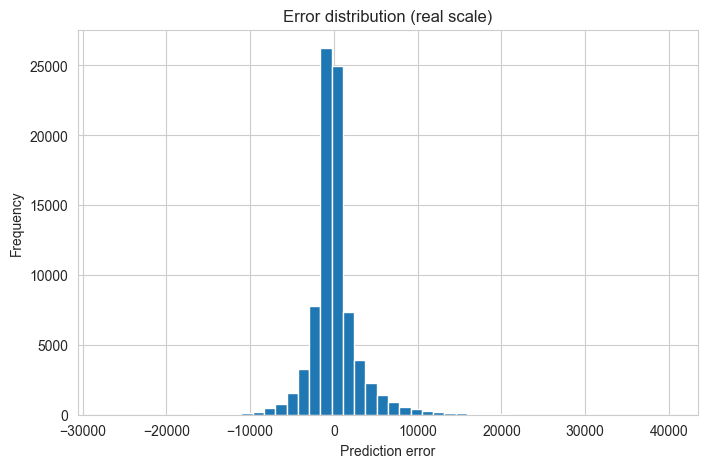

In [53]:
# Histogram ukazuje rozdelenie chyby modelu a umožňuje identifikovať systematické odchýlky alebo extrémne chyby.

_, _, _, y_true_real, y_pred_real = real_sage

errors = y_true_real - y_pred_real

plt.figure(figsize=(8,5))
plt.hist(errors.reshape(-1), bins=50)
plt.title("Error distribution (real scale)")
plt.xlabel("Prediction error")
plt.ylabel("Frequency")
plt.show()

# Распределение ошибки имеет выраженную концентрацию вокруг нуля с правосторонним хвостом, что означает, что модель в большинстве случаев предсказывает близко к реальному значению, однако при высоких нагрузках наблюдаются редкие, но значительные ошибки переоценки или недооценки.

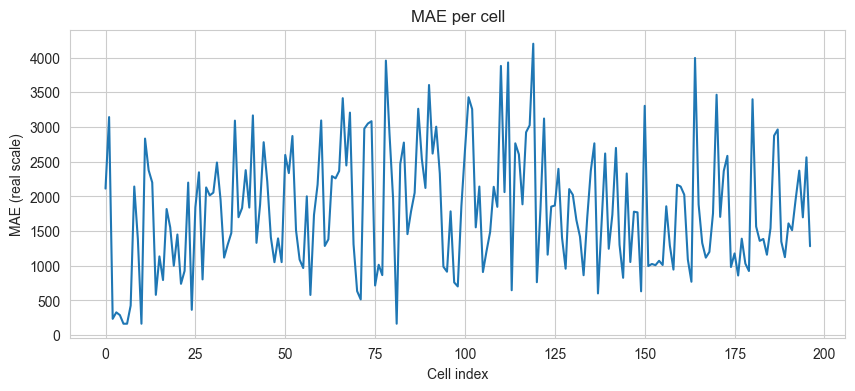

In [54]:
# MAE podľa jednotlivých buniek (per-cell error). Umožňuje identifikovať, ktoré základňové stanice sú pre model problematickejšie a kde je predikcia menej presná.

mae_per_cell = np.mean(np.abs(y_true_real - y_pred_real), axis=0)

plt.figure(figsize=(10,4))
plt.plot(mae_per_cell)
plt.title("MAE per cell")
plt.xlabel("Cell index")
plt.ylabel("MAE (real scale)")
plt.show()

# График MAE по станциям показывает значительную неоднородность ошибки между клетками, что свидетельствует о том, что модель хуже предсказывает станции с более сложной динамикой или высокой вариативностью нагрузки.

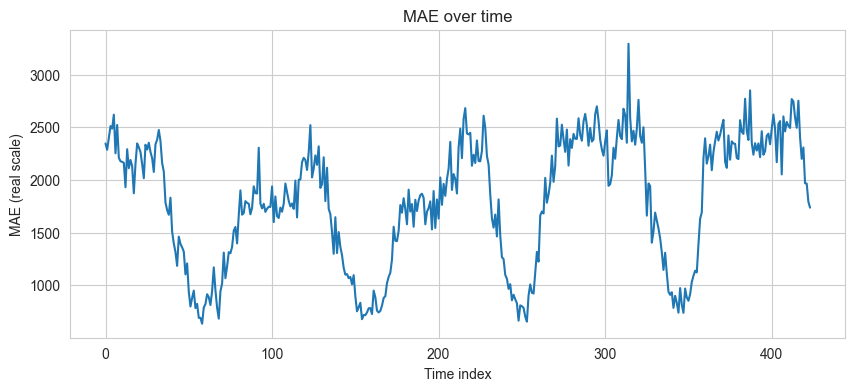

In [55]:
# MAE v čase (error over time). Pomáha pochopiť stabilitu modelu a jeho správanie pri rôznych úrovniach záťaže siete.
mae_per_time = np.mean(np.abs(y_true_real - y_pred_real), axis=1)

plt.figure(figsize=(10,4))
plt.plot(mae_per_time)
plt.title("MAE over time")
plt.xlabel("Time index")
plt.ylabel("MAE (real scale)")
plt.show()



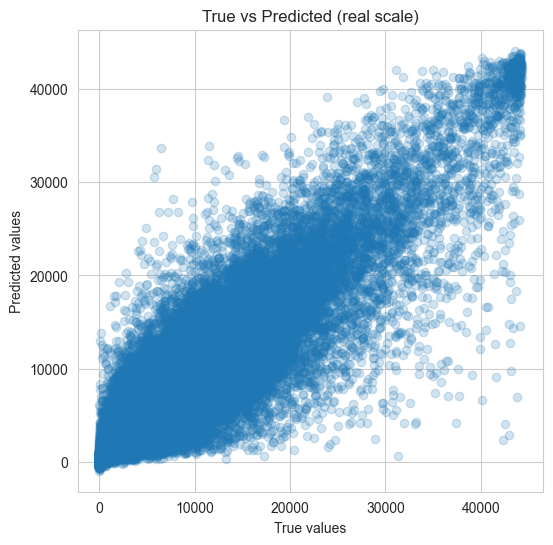

In [56]:
# Scatter plot: skutočné vs. predikované hodnoty.  Ak body ležia blízko diagonály, model dosahuje vysokú presnosť; odchýlky od diagonály indikujú predikčné chyby.

plt.figure(figsize=(6,6))
plt.scatter(y_true_real.reshape(-1),
            y_pred_real.reshape(-1),
            alpha=0.2)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted (real scale)")
plt.show()

Bol zobrazený priebeh tréningovej straty a validačnej chyby počas epoch, čo umožňuje kontrolovať stabilitu učenia. Grafy pomáhajú identifikovať preučenie alebo potrebu úpravy hyperparametrov.

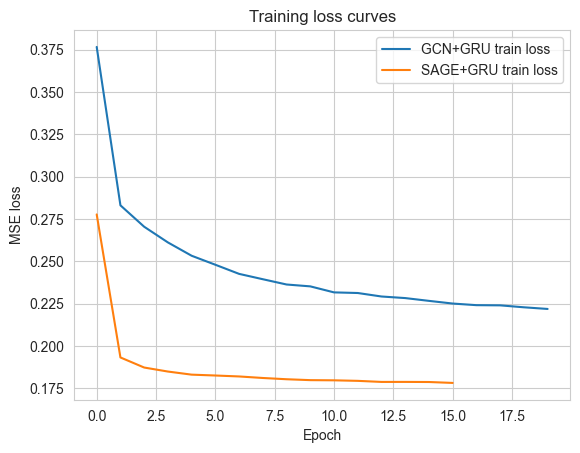

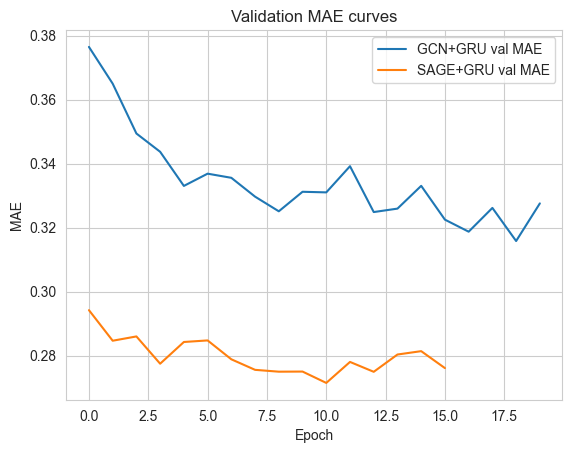

In [167]:
plt.figure()
plt.plot(hist_gcn["train_loss"], label="GCN+GRU train loss")
plt.plot(hist_sage["train_loss"], label="SAGE+GRU train loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss curves")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist_gcn["val_mae"], label="GCN+GRU val MAE")
plt.plot(hist_sage["val_mae"], label="SAGE+GRU val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Validation MAE curves")
plt.legend()
plt.show()


Bola zobrazená ukážka predikcií a skutočných hodnôt pre jednu bunku, aby sa overilo, že model produkuje zmysluplné výstupy.

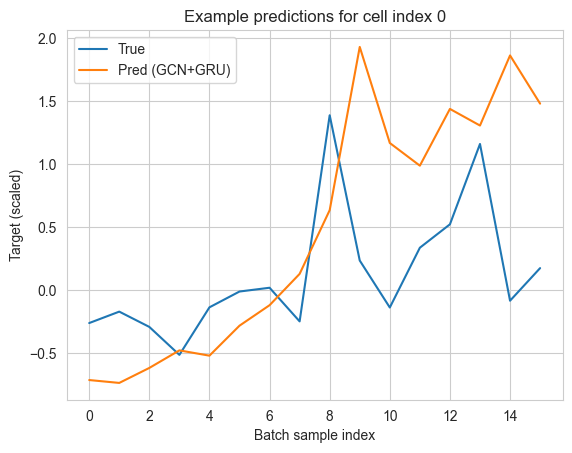

In [168]:
@torch.no_grad()
def predict_one_batch(model, loader):
    model.eval()
    batch = next(iter(loader))
    Xb, yb = unpack_batch(batch)
    Xb = Xb.to(device)
    yb = yb.to(device)[:, 0, :]   # [B, N]

    if isinstance(model, GCN_GRU):
        pred = model(Xb, edge_index_t, edge_weight_t)
    else:
        pred = model(Xb, edge_index_t)

    return yb.cpu().numpy(), pred.cpu().numpy()

y_true_b, y_pred_b = predict_one_batch(gcn_gru, test_loader)

cell_id = 0  # change to any cell index you want
plt.figure()
plt.plot(y_true_b[:, cell_id], label="True")
plt.plot(y_pred_b[:, cell_id], label="Pred (GCN+GRU)")
plt.xlabel("Batch sample index")
plt.ylabel("Target (scaled)")
plt.title(f"Example predictions for cell index {cell_id}")
plt.legend()
plt.show()


In [170]:
real_time = all_times[t]
print(real_time)

2025-09-01T01:45:00.000000000


In [171]:
@torch.no_grad()
def predict_full_test(model):
    model.eval()

    all_preds = []
    all_true = []
    all_t = []

    for batch in test_loader:
        Xb, yb, tb = batch  # ВАЖНО: используем t

        Xb = Xb.to(device)
        yb = yb[:, 0, :]  # [B, N]

        if isinstance(model, GCN_GRU):
            pred = model(Xb, edge_index_t, edge_weight_t)
        else:
            pred = model(Xb, edge_index_t)

        all_preds.append(pred.cpu().numpy())
        all_true.append(yb.numpy())
        all_t.append(tb.numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_preds)
    t_all = np.concatenate(all_t)

    return y_true, y_pred, t_all


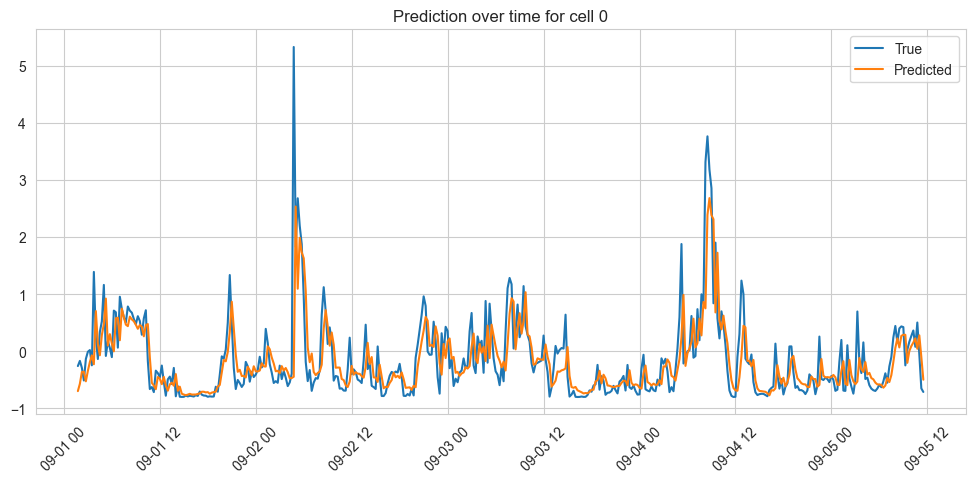

In [172]:
y_true, y_pred, t_all = predict_full_test(sage_gru)

cell_id = 0  # выбери любую станцию

# Преобразуем индексы времени в реальные даты
real_dates = all_times[t_all]

plt.figure(figsize=(12,5))
plt.plot(real_dates, y_true[:, cell_id], label="True")
plt.plot(real_dates, y_pred[:, cell_id], label="Predicted")
plt.xticks(rotation=45)
plt.title(f"Prediction over time for cell {cell_id}")
plt.legend()
plt.show()


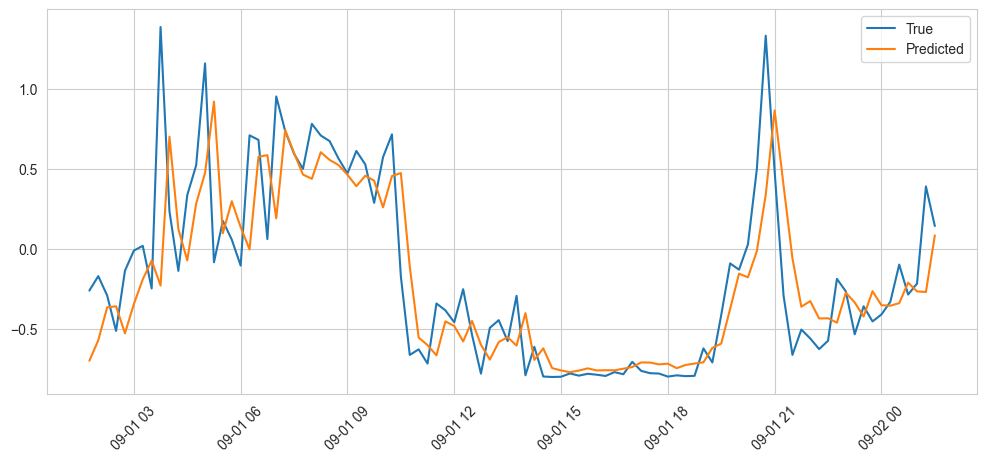

In [173]:
mask = (real_dates >= real_dates[0]) & (real_dates < real_dates[0] + np.timedelta64(1, 'D'))

plt.figure(figsize=(12,5))
plt.plot(real_dates[mask], y_true[mask, cell_id], label="True")
plt.plot(real_dates[mask], y_pred[mask, cell_id], label="Predicted")
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [175]:
# Получаем все предсказания на test
@torch.no_grad()
def get_full_test_predictions(model):
    model.eval()

    all_preds = []
    all_true = []
    all_t = []

    for batch in test_loader:
        Xb, yb, tb = batch

        Xb = Xb.to(device)
        yb = yb[:, 0, :]  # [B, N]

        if isinstance(model, GCN_GRU):
            pred = model(Xb, edge_index_t, edge_weight_t)
        else:
            pred = model(Xb, edge_index_t)

        all_preds.append(pred.cpu().numpy())
        all_true.append(yb.numpy())
        all_t.append(tb.numpy())

    y_true = np.concatenate(all_true)   # shape [samples, N]
    y_pred = np.concatenate(all_preds)
    t_all  = np.concatenate(all_t)

    return y_true, y_pred, t_all

In [176]:
y_true, y_pred, t_all = get_full_test_predictions(sage_gru)

import pandas as pd

rows = []

for i in range(len(t_all)):
    time_index_value = t_all[i]
    real_time = all_times[time_index_value]  # реальный timestamp

    for cell_idx, cell_name in enumerate(cells):
        rows.append({
            "time": real_time,
            "cell": cell_name,
            "true_value_scaled": y_true[i, cell_idx],
            "pred_value_scaled": y_pred[i, cell_idx],
            "abs_error": abs(y_true[i, cell_idx] - y_pred[i, cell_idx])
        })

df_predictions = pd.DataFrame(rows)

df_predictions.head()

,time,cell,true_value_scaled,pred_value_scaled,abs_error
0,2025-09-01 01:45:00,TK1ALP1,-0.260909,-0.700308,0.439399
1,2025-09-01 01:45:00,TK1ALP2,1.031027,1.733953,0.702926
2,2025-09-01 01:45:00,TK1ARE1,-0.802799,-0.870659,0.067859
3,2025-09-01 01:45:00,TK1ARE2,-0.804942,-0.879888,0.074946
4,2025-09-01 01:45:00,TK1ARE3,-0.757511,-0.868192,0.110681


In [177]:
# Получаем scaler
target_scaler_mean = scaler.mean_[target_idx]
target_scaler_std  = scaler.scale_[target_idx]

df_predictions["true_real"] = (
    df_predictions["true_value_scaled"] * target_scaler_std + target_scaler_mean
)

df_predictions["pred_real"] = (
    df_predictions["pred_value_scaled"] * target_scaler_std + target_scaler_mean
)

df_predictions.head()

,time,cell,true_value_scaled,pred_value_scaled,abs_error,true_real,pred_real
0,2025-09-01 01:45:00,TK1ALP1,-0.260909,-0.700308,0.439399,3813.0,737.395508
1,2025-09-01 01:45:00,TK1ALP2,1.031027,1.733953,0.702926,12856.0,17776.175781
2,2025-09-01 01:45:00,TK1ARE1,-0.802799,-0.870659,0.067859,20.0,-454.984375
3,2025-09-01 01:45:00,TK1ARE2,-0.804942,-0.879888,0.074946,5.0,-519.586914
4,2025-09-01 01:45:00,TK1ARE3,-0.757511,-0.868192,0.110681,337.0,-437.719727
